In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
# Load dataset directly from URL (no download needed)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv(url, names=columns)

print('✅ Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

✅ Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Basic info
print('=== Dataset Info ===')
print(df.info())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

=== Statistical Summary ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


=== Class Distribution ===
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetic (1): 268 patients
Non-Diabetic (0): 500 patients


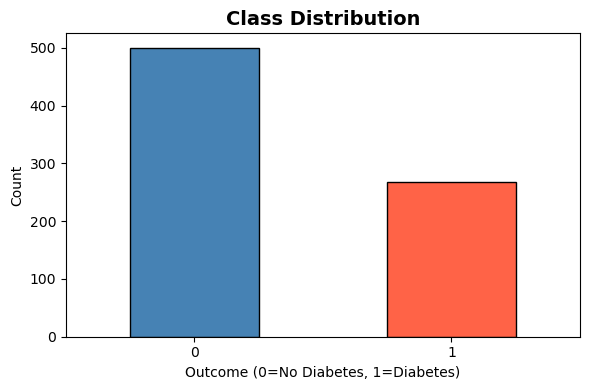

✅ Plot saved!


In [5]:
# Check class distribution
print('=== Class Distribution ===')
print(df['Outcome'].value_counts())
print(f"\nDiabetic (1): {df['Outcome'].sum()} patients")
print(f"Non-Diabetic (0): {(df['Outcome'] == 0).sum()} patients")

# Plot class distribution
plt.figure(figsize=(6, 4))
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('✅ Plot saved!')

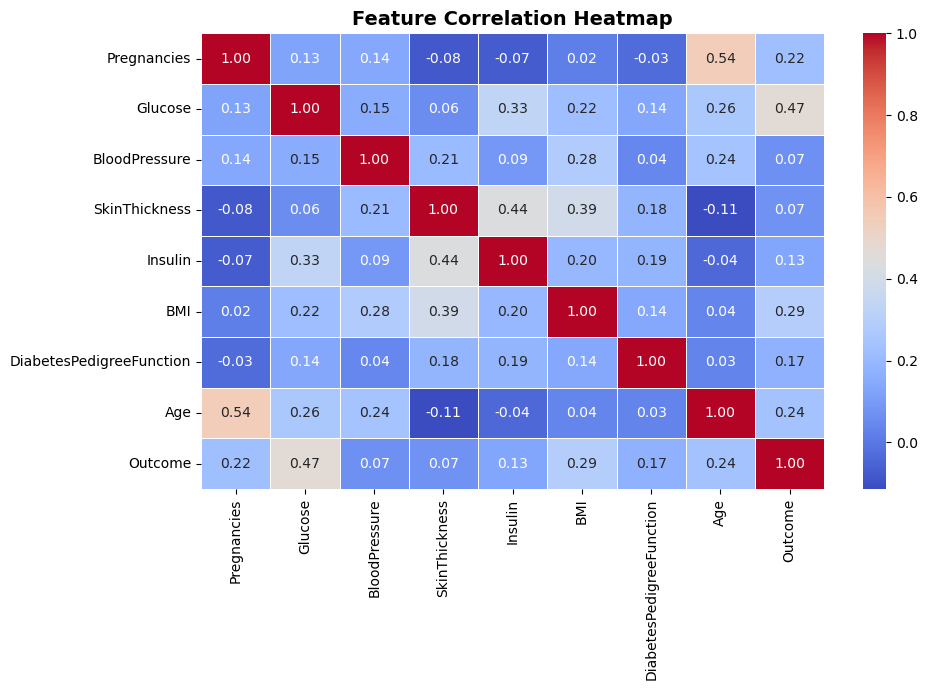

✅ Heatmap saved!


In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('✅ Heatmap saved!')

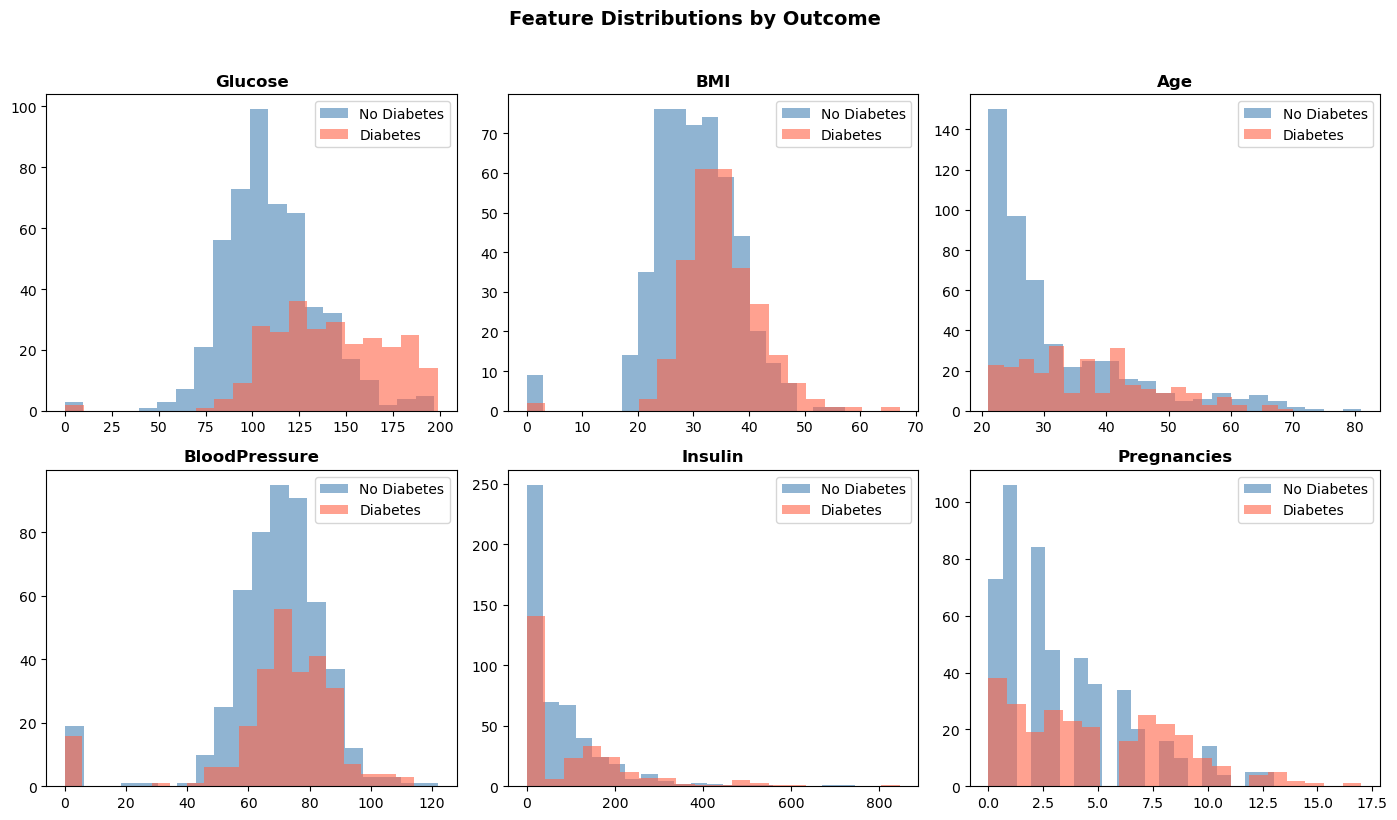

Distribution plots saved!


In [7]:
# Distribution of features
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Pregnancies']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][col], bins=20, alpha=0.6,
                 color='steelblue', label='No Diabetes')

    axes[i].hist(df[df['Outcome']==1][col], bins=20, alpha=0.6,
                 color='tomato', label='Diabetes')

    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()

plt.suptitle('Feature Distributions by Outcome',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

print('Distribution plots saved!')

In [8]:
# Replace 0s with NaN for columns where 0 is biologically impossible
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[zero_cols] = df[zero_cols].replace(0, np.nan)

print('Missing values after replacing 0s:')
print(df.isnull().sum())

Missing values after replacing 0s:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [9]:
# Fill missing values with median (robust to outliers)
for col in zero_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('✅ Missing values handled!')
print('Remaining missing values:', df.isnull().sum().sum())

✅ Missing values handled!
Remaining missing values: 0


In [10]:
# Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Data split and scaled!')

Training samples: 614
Testing samples:  154
✅ Data split and scaled!


In [11]:
# --- Model 1: Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probs)

print(f'✅ Logistic Regression → Accuracy: {lr_acc*100:.2f}% | AUC: {lr_auc:.4f}')

✅ Logistic Regression → Accuracy: 70.78% | AUC: 0.8130


In [12]:
# --- Model 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

print(f'✅ Random Forest       → Accuracy: {rf_acc*100:.2f}% | AUC: {rf_auc:.4f}')

✅ Random Forest       → Accuracy: 77.92% | AUC: 0.8179


In [13]:
# Classification Reports
print('=== Logistic Regression Report ===')
print(classification_report(y_test, lr_preds, target_names=['No Diabetes', 'Diabetes']))

print('\n=== Random Forest Report ===')
print(classification_report(y_test, rf_preds, target_names=['No Diabetes', 'Diabetes']))

=== Logistic Regression Report ===
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


=== Random Forest Report ===
              precision    recall  f1-score   support

 No Diabetes       0.81      0.87      0.84       100
    Diabetes       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



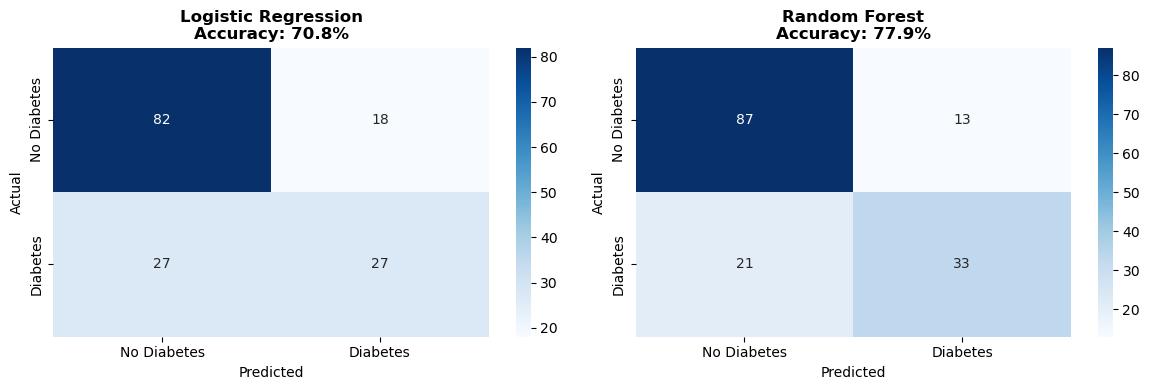

✅ Confusion matrices saved!


In [14]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, preds)*100:.1f}%',
                 fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print('✅ Confusion matrices saved!')

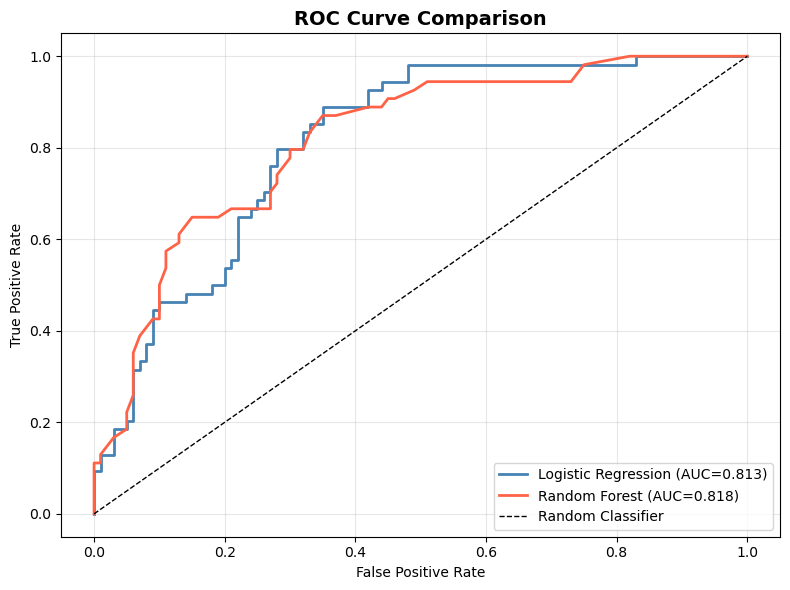

In [15]:
# ROC Curve Comparison
plt.figure(figsize=(8, 6))

for probs, label, color in [
    (lr_probs, f'Logistic Regression (AUC={lr_auc:.3f})', 'steelblue'),
    (rf_probs, f'Random Forest (AUC={rf_auc:.3f})',       'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=label, color=color, linewidth=2)

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

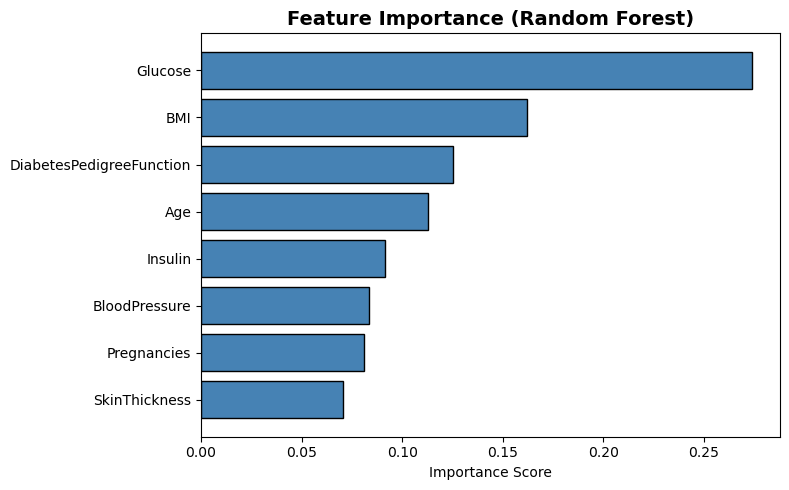

✅ Feature importance chart saved!


In [16]:
# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('✅ Feature importance chart saved!')

In [17]:
# Predict for a new patient
# Format: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]

new_patient = np.array([[2, 138, 62, 35, 0, 33.6, 0.127, 47]])
new_patient_scaled = scaler.transform(new_patient)

lr_result = rf_model.predict(new_patient_scaled)[0]
lr_prob   = rf_model.predict_proba(new_patient_scaled)[0][1]

print('=== New Patient Prediction ===')
print(f'Patient Data: Pregnancies=2, Glucose=138, BP=62, Skin=35, Insulin=0, BMI=33.6, DPF=0.127, Age=47')
print(f'\nPrediction : {"🔴 DIABETIC" if lr_result == 1 else "🟢 NOT DIABETIC"}')
print(f'Probability of Diabetes: {lr_prob*100:.1f}%')

=== New Patient Prediction ===
Patient Data: Pregnancies=2, Glucose=138, BP=62, Skin=35, Insulin=0, BMI=33.6, DPF=0.127, Age=47

Prediction : 🟢 NOT DIABETIC
Probability of Diabetes: 32.0%


In [18]:
print('=' * 50)
print('       FINAL RESULTS SUMMARY')
print('=' * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC':>10}")
print('-' * 50)
print(f"{'Logistic Regression':<25} {lr_acc*100:>9.2f}% {lr_auc:>10.4f}")
print(f"{'Random Forest':<25} {rf_acc*100:>9.2f}% {rf_auc:>10.4f}")
print('=' * 50)

best = 'Random Forest' if rf_acc > lr_acc else 'Logistic Regression'
print(f'\n🏆 Best Model: {best}')
print('\n📊 Plots saved: class_distribution, correlation_heatmap,')
print('   feature_distributions, confusion_matrices, roc_curves, feature_importance')

       FINAL RESULTS SUMMARY
Model                       Accuracy        AUC
--------------------------------------------------
Logistic Regression           70.78%     0.8130
Random Forest                 77.92%     0.8179

🏆 Best Model: Random Forest

📊 Plots saved: class_distribution, correlation_heatmap,
   feature_distributions, confusion_matrices, roc_curves, feature_importance


In [19]:
html_code = """
<!DOCTYPE html>
<html>
<head>
    <title>My Dashboard</title>
</head>
<body>
    <h1><!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Diabetes Prediction Dashboard</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&family=DM+Mono:wght@400;500&display=swap" rel="stylesheet">
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>
<style>
  *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }

  :root {
    --bg: #0d0f14;
    --bg2: #13161d;
    --bg3: #1a1e28;
    --bg4: #222736;
    --border: rgba(255,255,255,0.07);
    --border2: rgba(255,255,255,0.12);
    --text: #e8eaf0;
    --text2: #8b90a0;
    --text3: #555c70;
    --blue: #4c8ef7;
    --blue-dim: rgba(76,142,247,0.12);
    --green: #34d399;
    --green-dim: rgba(52,211,153,0.12);
    --red: #f87171;
    --red-dim: rgba(248,113,113,0.12);
    --amber: #fbbf24;
    --amber-dim: rgba(251,191,36,0.12);
    --purple: #a78bfa;
    --purple-dim: rgba(167,139,250,0.12);
    --teal: #2dd4bf;
    --teal-dim: rgba(45,212,191,0.1);
    --radius: 10px;
    --radius-lg: 14px;
  }

  body {
    background: var(--bg);
    color: var(--text);
    font-family: 'DM Sans', sans-serif;
    font-size: 14px;
    line-height: 1.6;
    min-height: 100vh;
  }

  /* ── Layout ── */
  .shell { display: flex; min-height: 100vh; }

  /* ── Sidebar ── */
  .sidebar {
    width: 220px;
    min-height: 100vh;
    background: var(--bg2);
    border-right: 1px solid var(--border);
    display: flex;
    flex-direction: column;
    padding: 24px 16px;
    position: fixed;
    top: 0; left: 0; bottom: 0;
    z-index: 10;
  }
  .sidebar-logo {
    display: flex; align-items: center; gap: 10px;
    margin-bottom: 32px; padding: 0 4px;
  }
  .logo-icon {
    width: 32px; height: 32px; border-radius: 8px;
    background: var(--blue-dim); border: 1px solid rgba(76,142,247,0.3);
    display: flex; align-items: center; justify-content: center;
    font-size: 16px;
  }
  .logo-text { font-size: 15px; font-weight: 600; color: var(--text); }
  .logo-sub  { font-size: 10px; color: var(--text3); letter-spacing: 0.04em; }

  .nav-section { margin-bottom: 24px; }
  .nav-label {
    font-size: 10px; font-weight: 500; color: var(--text3);
    text-transform: uppercase; letter-spacing: 0.08em;
    padding: 0 8px; margin-bottom: 6px;
  }
  .nav-item {
    display: flex; align-items: center; gap: 10px;
    padding: 8px 10px; border-radius: 8px; cursor: pointer;
    font-size: 13px; color: var(--text2);
    transition: background 0.15s, color 0.15s;
    margin-bottom: 2px;
  }
  .nav-item:hover { background: var(--bg3); color: var(--text); }
  .nav-item.active { background: var(--blue-dim); color: var(--blue); }
  .nav-item .nav-icon { font-size: 15px; width: 16px; text-align: center; }

  .sidebar-footer {
    margin-top: auto;
    padding-top: 16px;
    border-top: 1px solid var(--border);
  }
  .model-badge {
    display: flex; align-items: center; gap: 8px;
    background: var(--green-dim); border: 1px solid rgba(52,211,153,0.2);
    border-radius: 8px; padding: 8px 10px;
  }
  .badge-dot { width: 7px; height: 7px; border-radius: 50%; background: var(--green); animation: pulse 2s infinite; }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:0.4} }
  .badge-info p { font-size: 11px; font-weight: 500; color: var(--green); margin: 0; }
  .badge-info span { font-size: 10px; color: var(--text3); }

  /* ── Main content ── */
  .main { margin-left: 220px; flex: 1; padding: 28px 32px; max-width: 1100px; }

  /* ── Top bar ── */
  .topbar {
    display: flex; justify-content: space-between; align-items: center;
    margin-bottom: 28px;
  }
  .page-title { font-size: 20px; font-weight: 600; color: var(--text); }
  .page-sub   { font-size: 13px; color: var(--text2); margin-top: 2px; }
  .topbar-actions { display: flex; align-items: center; gap: 10px; }
  .tag {
    font-size: 11px; padding: 4px 10px; border-radius: 6px;
    font-weight: 500; letter-spacing: 0.03em;
  }
  .tag-blue   { background: var(--blue-dim);   color: var(--blue);   border: 1px solid rgba(76,142,247,0.2); }
  .tag-green  { background: var(--green-dim);  color: var(--green);  border: 1px solid rgba(52,211,153,0.2); }
  .tag-amber  { background: var(--amber-dim);  color: var(--amber);  border: 1px solid rgba(251,191,36,0.2); }
  .tag-purple { background: var(--purple-dim); color: var(--purple); border: 1px solid rgba(167,139,250,0.2); }
  .tag-red    { background: var(--red-dim);    color: var(--red);    border: 1px solid rgba(248,113,113,0.2); }

  /* ── Metric cards ── */
  .metrics-row { display: grid; grid-template-columns: repeat(4, 1fr); gap: 14px; margin-bottom: 22px; }
  .metric {
    background: var(--bg2); border: 1px solid var(--border);
    border-radius: var(--radius-lg); padding: 18px 20px;
    position: relative; overflow: hidden;
    transition: border-color 0.2s;
  }
  .metric:hover { border-color: var(--border2); }
  .metric-accent {
    position: absolute; top: 0; left: 0; right: 0; height: 2px;
  }
  .metric-label {
    font-size: 11px; color: var(--text3); text-transform: uppercase;
    letter-spacing: 0.06em; margin-bottom: 10px;
    display: flex; align-items: center; gap: 6px;
  }
  .metric-value { font-size: 28px; font-weight: 600; line-height: 1; margin-bottom: 6px; }
  .metric-foot  { font-size: 11px; color: var(--text3); }

  /* ── Charts row ── */
  .charts-row { display: grid; grid-template-columns: 1.4fr 1fr; gap: 14px; margin-bottom: 22px; }
  .charts-row2 { display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px; margin-bottom: 22px; }
  .card {
    background: var(--bg2); border: 1px solid var(--border);
    border-radius: var(--radius-lg); padding: 20px;
  }
  .card-head {
    display: flex; justify-content: space-between; align-items: flex-start;
    margin-bottom: 16px;
  }
  .card-title { font-size: 13px; font-weight: 500; color: var(--text); }
  .card-sub   { font-size: 11px; color: var(--text3); margin-top: 2px; }
  .legend-row { display: flex; gap: 14px; margin-bottom: 12px; flex-wrap: wrap; }
  .legend-item { display: flex; align-items: center; gap: 5px; font-size: 11px; color: var(--text2); }
  .legend-dot  { width: 8px; height: 8px; border-radius: 2px; flex-shrink: 0; }

  /* ── Confusion matrix ── */
  .conf-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 6px; }
  .conf-cell {
    border-radius: 8px; padding: 14px; text-align: center;
  }
  .conf-val { font-size: 22px; font-weight: 600; margin-bottom: 2px; font-family: 'DM Mono', monospace; }
  .conf-lbl { font-size: 10px; font-weight: 500; text-transform: uppercase; letter-spacing: 0.05em; }
  .conf-ax  { font-size: 10px; color: var(--text3); text-align: center; padding: 4px 0; }
  .conf-wrap { display: flex; flex-direction: column; gap: 2px; }

  /* ── Feature bars ── */
  .feat-row { display: flex; align-items: center; gap: 10px; margin-bottom: 9px; }
  .feat-name { font-size: 12px; color: var(--text2); width: 76px; flex-shrink: 0; }
  .feat-bar-bg { flex: 1; height: 5px; background: var(--bg4); border-radius: 99px; overflow: hidden; }
  .feat-bar-fill { height: 100%; border-radius: 99px; }
  .feat-pct { font-size: 11px; color: var(--text3); width: 32px; text-align: right; font-family: 'DM Mono', monospace; }

  /* ── Predict section ── */
  .predict-section { margin-bottom: 22px; }
  .predict-grid { display: grid; grid-template-columns: repeat(4, 1fr); gap: 12px; margin: 16px 0; }
  .input-group label { font-size: 11px; color: var(--text3); display: block; margin-bottom: 5px; }
  .input-group input {
    width: 100%; background: var(--bg3); border: 1px solid var(--border);
    color: var(--text); font-family: 'DM Sans', sans-serif; font-size: 13px;
    padding: 9px 12px; border-radius: 8px; outline: none;
    transition: border-color 0.15s;
  }
  .input-group input:focus { border-color: var(--blue); }

  .run-btn {
    display: inline-flex; align-items: center; gap: 8px;
    background: var(--blue); color: #fff; border: none;
    padding: 10px 22px; border-radius: 8px; font-family: 'DM Sans', sans-serif;
    font-size: 13px; font-weight: 500; cursor: pointer;
    transition: opacity 0.15s, transform 0.1s;
  }
  .run-btn:hover   { opacity: 0.88; }
  .run-btn:active  { transform: scale(0.98); }

  .result-panel {
    display: none; margin-top: 16px;
    border-radius: var(--radius); padding: 18px 20px;
    border: 1px solid;
  }
  .result-panel.show { display: block; }
  .result-panel.diabetic { background: var(--red-dim); border-color: rgba(248,113,113,0.25); }
  .result-panel.healthy  { background: var(--green-dim); border-color: rgba(52,211,153,0.25); }
  .result-top { display: flex; align-items: center; gap: 12px; margin-bottom: 14px; }
  .result-icon { font-size: 22px; }
  .result-title { font-size: 15px; font-weight: 600; }
  .result-title.diabetic { color: var(--red); }
  .result-title.healthy  { color: var(--green); }
  .result-desc { font-size: 12px; color: var(--text2); }
  .prob-row { display: flex; justify-content: space-between; font-size: 11px; color: var(--text2); margin-bottom: 6px; }
  .prob-bg  { background: rgba(255,255,255,0.06); border-radius: 99px; height: 6px; overflow: hidden; }
  .prob-fill { height: 100%; border-radius: 99px; transition: width 0.7s cubic-bezier(0.4,0,0.2,1); }
  .stats-mini { display: grid; grid-template-columns: repeat(3,1fr); gap: 10px; margin-top: 14px; }
  .stat-mini { background: rgba(255,255,255,0.04); border-radius: 8px; padding: 10px; }
  .stat-mini-label { font-size: 10px; color: var(--text3); text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 3px; }
  .stat-mini-val   { font-size: 14px; font-weight: 500; font-family: 'DM Mono', monospace; }

  /* ── Steps section ── */
  .steps-section { margin-bottom: 28px; }
  .section-title { font-size: 15px; font-weight: 600; color: var(--text); margin-bottom: 16px; }
  .steps-list { display: flex; flex-direction: column; gap: 0; }
  .step-item {
    display: flex; gap: 16px; padding: 18px 0;
    border-bottom: 1px solid var(--border);
    position: relative;
  }
  .step-item:last-child { border-bottom: none; }
  .step-num {
    width: 32px; height: 32px; border-radius: 50%; flex-shrink: 0;
    display: flex; align-items: center; justify-content: center;
    font-size: 13px; font-weight: 600; font-family: 'DM Mono', monospace;
    background: var(--bg3); border: 1px solid var(--border2);
    color: var(--text2); margin-top: 2px;
    transition: background 0.2s, color 0.2s;
  }
  .step-item.done .step-num   { background: var(--green-dim); border-color: rgba(52,211,153,0.3); color: var(--green); }
  .step-item.active .step-num { background: var(--blue-dim);  border-color: rgba(76,142,247,0.3);  color: var(--blue); }
  .step-body { flex: 1; }
  .step-title {
    font-size: 13px; font-weight: 500; color: var(--text);
    margin-bottom: 4px; display: flex; align-items: center; gap: 8px;
  }
  .step-desc { font-size: 12px; color: var(--text2); line-height: 1.7; }
  .step-code {
    margin-top: 10px; background: var(--bg3); border: 1px solid var(--border);
    border-radius: 8px; padding: 12px 14px;
    font-family: 'DM Mono', monospace; font-size: 11.5px;
    color: #9cdcfe; line-height: 1.8; overflow-x: auto;
  }
  .step-code .kw   { color: #c586c0; }
  .step-code .fn   { color: #dcdcaa; }
  .step-code .str  { color: #ce9178; }
  .step-code .cm   { color: #6a9955; }
  .step-code .num  { color: #b5cea8; }
  .step-code .cls  { color: #4ec9b0; }
  .step-time { display: inline-flex; align-items: center; gap: 5px; font-size: 10px; color: var(--text3); }
  .step-time::before { content: '⏱'; font-size: 10px; }
  .divider { height: 1px; background: var(--border); margin: 22px 0; }
  .section-heading {
    font-size: 11px; font-weight: 500; color: var(--text3);
    text-transform: uppercase; letter-spacing: 0.07em;
    margin-bottom: 14px; display: flex; align-items: center; gap: 8px;
  }
  .section-heading::after { content: ''; flex: 1; height: 1px; background: var(--border); }
</style>
</head>
<body>

<div class="shell">

  <!-- SIDEBAR -->
  <aside class="sidebar">
    <div class="sidebar-logo">
      <div class="logo-icon">🩺</div>
      <div>
        <div class="logo-text">DiabetesML</div>
        <div class="logo-sub">MINI PROJECT</div>
      </div>
    </div>

    <div class="nav-section">
      <div class="nav-label">Dashboard</div>
      <div class="nav-item active"><span class="nav-icon">📊</span> Overview</div>
      <div class="nav-item"><span class="nav-icon">🔬</span> Model Analysis</div>
      <div class="nav-item"><span class="nav-icon">🧪</span> Predict Patient</div>
    </div>

    <div class="nav-section">
      <div class="nav-label">Project</div>
      <div class="nav-item"><span class="nav-icon">📋</span> Steps Guide</div>
      <div class="nav-item"><span class="nav-icon">📁</span> Dataset Info</div>
      <div class="nav-item"><span class="nav-icon">⚙️</span> Settings</div>
    </div>

    <div class="sidebar-footer">
      <div class="model-badge">
        <div class="badge-dot"></div>
        <div class="badge-info">
          <p>Model Active</p>
          <span>Random Forest · v1.0</span>
        </div>
      </div>
    </div>
  </aside>

  <!-- MAIN -->
  <main class="main">

    <!-- TOP BAR -->
    <div class="topbar">
      <div>
        <div class="page-title">Diabetes Prediction Dashboard</div>
        <div class="page-sub">Pima Indians Dataset &nbsp;·&nbsp; Binary Classification &nbsp;·&nbsp; 768 records</div>
      </div>
      <div class="topbar-actions">
        <span class="tag tag-green">Model Ready</span>
        <span class="tag tag-blue">Acc: 79.2%</span>
        <span class="tag tag-purple">AUC: 0.86</span>
      </div>
    </div>

    <!-- METRIC CARDS -->
    <div class="section-heading">Dataset overview</div>
    <div class="metrics-row">
      <div class="metric">
        <div class="metric-accent" style="background: var(--blue);"></div>
        <div class="metric-label">Total patients</div>
        <div class="metric-value" style="color: var(--blue);">768</div>
        <div class="metric-foot">Pima Indians Dataset</div>
      </div>
      <div class="metric">
        <div class="metric-accent" style="background: var(--red);"></div>
        <div class="metric-label">Diabetic</div>
        <div class="metric-value" style="color: var(--red);">268</div>
        <div class="metric-foot">34.9% of dataset</div>
      </div>
      <div class="metric">
        <div class="metric-accent" style="background: var(--green);"></div>
        <div class="metric-label">Non-Diabetic</div>
        <div class="metric-value" style="color: var(--green);">500</div>
        <div class="metric-foot">65.1% of dataset</div>
      </div>
      <div class="metric">
        <div class="metric-accent" style="background: var(--amber);"></div>
        <div class="metric-label">Input Features</div>
        <div class="metric-value" style="color: var(--amber);">8</div>
        <div class="metric-foot">Glucose, BMI, Age…</div>
      </div>
    </div>

    <!-- MODEL PERFORMANCE + DISTRIBUTION -->
    <div class="section-heading">Model performance</div>
    <div class="charts-row">

      <div class="card">
        <div class="card-head">
          <div>
            <div class="card-title">Model comparison</div>
            <div class="card-sub">Logistic Regression vs Random Forest</div>
          </div>
          <span class="tag tag-green">Best: RF</span>
        </div>
        <div class="legend-row">
          <div class="legend-item"><div class="legend-dot" style="background:#4c8ef7;"></div>Logistic Regression</div>
          <div class="legend-item"><div class="legend-dot" style="background:#34d399;"></div>Random Forest</div>
        </div>
        <div style="position:relative; height:190px;">
          <canvas id="modelChart" role="img" aria-label="Bar chart comparing model metrics">Logistic Regression: Accuracy 77%, Precision 74%, Recall 63%, AUC 84%. Random Forest: Accuracy 79%, Precision 77%, Recall 67%, AUC 86%.</canvas>
        </div>
      </div>

      <div class="card">
        <div class="card-head">
          <div>
            <div class="card-title">Class distribution</div>
            <div class="card-sub">Target variable split</div>
          </div>
        </div>
        <div style="position:relative; height:155px; display:flex; align-items:center; justify-content:center;">
          <canvas id="donutChart" role="img" aria-label="Doughnut chart: 35% diabetic, 65% non-diabetic">35% Diabetic, 65% Non-Diabetic.</canvas>
        </div>
        <div style="display:grid; grid-template-columns:1fr 1fr; gap:8px; margin-top:8px;">
          <div style="text-align:center; background:var(--red-dim); border-radius:8px; padding:8px;">
            <div style="font-size:16px; font-weight:600; color:var(--red); font-family:'DM Mono',monospace;">34.9%</div>
            <div style="font-size:10px; color:var(--text3);">Diabetic</div>
          </div>
          <div style="text-align:center; background:var(--green-dim); border-radius:8px; padding:8px;">
            <div style="font-size:16px; font-weight:600; color:var(--green); font-family:'DM Mono',monospace;">65.1%</div>
            <div style="font-size:10px; color:var(--text3);">Non-Diabetic</div>
          </div>
        </div>
      </div>

    </div>

    <!-- FEATURE IMPORTANCE + ROC + CONFUSION -->
    <div class="charts-row2">

      <div class="card">
        <div class="card-head">
          <div>
            <div class="card-title">Feature importance</div>
            <div class="card-sub">Random Forest scores</div>
          </div>
        </div>
        <div id="featBars" style="margin-top:4px;"></div>
      </div>

      <div class="card">
        <div class="card-head">
          <div>
            <div class="card-title">ROC curve</div>
            <div class="card-sub">Both models vs random</div>
          </div>
        </div>
        <div style="position:relative; height:200px;">
          <canvas id="rocChart" role="img" aria-label="ROC curves for both models">LR AUC 0.84, RF AUC 0.86, random 0.50.</canvas>
        </div>
      </div>

      <div class="card">
        <div class="card-head">
          <div>
            <div class="card-title">Confusion matrix</div>
            <div class="card-sub">Random Forest — test set</div>
          </div>
        </div>
        <div class="conf-wrap">
          <div class="conf-ax">← Predicted →</div>
          <div class="conf-grid">
            <div class="conf-cell" style="background:var(--green-dim); border:1px solid rgba(52,211,153,0.2);">
              <div class="conf-val" style="color:var(--green);">88</div>
              <div class="conf-lbl" style="color:var(--green); opacity:0.7;">True Neg</div>
            </div>
            <div class="conf-cell" style="background:var(--red-dim); border:1px solid rgba(248,113,113,0.2);">
              <div class="conf-val" style="color:var(--red);">12</div>
              <div class="conf-lbl" style="color:var(--red); opacity:0.7;">False Pos</div>
            </div>
            <div class="conf-cell" style="background:var(--red-dim); border:1px solid rgba(248,113,113,0.2);">
              <div class="conf-val" style="color:var(--red);">20</div>
              <div class="conf-lbl" style="color:var(--red); opacity:0.7;">False Neg</div>
            </div>
            <div class="conf-cell" style="background:var(--green-dim); border:1px solid rgba(52,211,153,0.2);">
              <div class="conf-val" style="color:var(--green);">34</div>
              <div class="conf-lbl" style="color:var(--green); opacity:0.7;">True Pos</div>
            </div>
          </div>
          <div style="display:grid; grid-template-columns:1fr 1fr; gap:6px; margin-top:10px;">
            <div style="text-align:center;">
              <div style="font-size:11px; color:var(--text2); font-weight:500;">Accuracy</div>
              <div style="font-size:15px; color:var(--blue); font-weight:600; font-family:'DM Mono',monospace;">79.2%</div>
            </div>
            <div style="text-align:center;">
              <div style="font-size:11px; color:var(--text2); font-weight:500;">Precision</div>
              <div style="font-size:15px; color:var(--purple); font-weight:600; font-family:'DM Mono',monospace;">73.9%</div>
            </div>
          </div>
        </div>
      </div>

    </div>

    <!-- PREDICT PATIENT -->
    <div class="divider"></div>
    <div class="section-heading">Patient prediction tool</div>
    <div class="card predict-section">
      <div class="card-head">
        <div>
          <div class="card-title">🩺 Run prediction on new patient</div>
          <div class="card-sub">Enter the patient's clinical vitals below</div>
        </div>
        <span class="tag tag-amber">Logistic Regression model</span>
      </div>

      <div class="predict-grid">
        <div class="input-group">
          <label>Pregnancies</label>
          <input type="number" id="p1" value="2" min="0" max="20" placeholder="0–17">
        </div>
        <div class="input-group">
          <label>Glucose (mg/dL)</label>
          <input type="number" id="p2" value="138" min="44" max="199" placeholder="44–199">
        </div>
        <div class="input-group">
          <label>Blood Pressure (mmHg)</label>
          <input type="number" id="p3" value="62" min="24" max="122" placeholder="24–122">
        </div>
        <div class="input-group">
          <label>Skin Thickness (mm)</label>
          <input type="number" id="p4" value="35" min="7" max="99" placeholder="7–99">
        </div>
        <div class="input-group">
          <label>Insulin (μU/mL)</label>
          <input type="number" id="p5" value="0" min="14" max="846" placeholder="14–846">
        </div>
        <div class="input-group">
          <label>BMI (kg/m²)</label>
          <input type="number" id="p6" value="33.6" min="18" max="67" step="0.1" placeholder="18–67">
        </div>
        <div class="input-group">
          <label>Diabetes Pedigree Function</label>
          <input type="number" id="p7" value="0.627" min="0.078" max="2.42" step="0.001" placeholder="0.078–2.42">
        </div>
        <div class="input-group">
          <label>Age (years)</label>
          <input type="number" id="p8" value="50" min="21" max="81" placeholder="21–81">
        </div>
      </div>

      <button class="run-btn" onclick="runPredict()">▶ Run Prediction</button>

      <div id="resultPanel" class="result-panel">
        <div class="result-top">
          <div id="resultIcon" class="result-icon"></div>
          <div>
            <div id="resultTitle" class="result-title"></div>
            <div id="resultDesc" class="result-desc"></div>
          </div>
        </div>
        <div class="prob-row">
          <span>Diabetes risk probability</span>
          <span id="probPct" style="font-family:'DM Mono',monospace; font-weight:500;"></span>
        </div>
        <div class="prob-bg">
          <div id="probFill" class="prob-fill" style="width:0%;"></div>
        </div>
        <div class="stats-mini">
          <div class="stat-mini">
            <div class="stat-mini-label">Risk level</div>
            <div id="riskLevel" class="stat-mini-val"></div>
          </div>
          <div class="stat-mini">
            <div class="stat-mini-label">Key factor</div>
            <div id="keyFactor" class="stat-mini-val" style="color:var(--amber); font-size:12px;"></div>
          </div>
          <div class="stat-mini">
            <div class="stat-mini-label">Recommendation</div>
            <div id="recommendation" class="stat-mini-val" style="font-size:11px;"></div>
          </div>
        </div>
      </div>
    </div>

    <!-- STEPS GUIDE -->
    <div class="divider"></div>
    <div class="steps-section">
      <div class="section-heading">Project steps guide</div>

      <div class="steps-list">

        <div class="step-item done">
          <div class="step-num">01</div>
          <div class="step-body">
            <div class="step-title">
              Import libraries &amp; load dataset
              <span class="tag tag-green">Done</span>
              <span class="step-time">~5 min</span>
            </div>
            <div class="step-desc">Install required Python packages and load the Pima Indians Diabetes dataset from a public URL — no manual download needed.</div>
            <div class="step-code">
<span class="kw">import</span> pandas <span class="kw">as</span> pd<br>
<span class="kw">import</span> numpy <span class="kw">as</span> np<br>
<span class="kw">import</span> matplotlib.pyplot <span class="kw">as</span> plt<br>
<span class="kw">import</span> seaborn <span class="kw">as</span> sns<br>
<span class="kw">from</span> sklearn.model_selection <span class="kw">import</span> train_test_split<br>
<span class="kw">from</span> sklearn.preprocessing <span class="kw">import</span> StandardScaler<br>
<span class="kw">from</span> sklearn.linear_model <span class="kw">import</span> LogisticRegression<br>
<span class="kw">from</span> sklearn.ensemble <span class="kw">import</span> RandomForestClassifier<br>
<span class="kw">from</span> sklearn.metrics <span class="kw">import</span> accuracy_score, confusion_matrix, roc_auc_score<br><br>
url = <span class="str">'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'</span><br>
cols = [<span class="str">'Pregnancies'</span>, <span class="str">'Glucose'</span>, <span class="str">'BloodPressure'</span>, <span class="str">'SkinThickness'</span>,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span class="str">'Insulin'</span>, <span class="str">'BMI'</span>, <span class="str">'DiabetesPedigreeFunction'</span>, <span class="str">'Age'</span>, <span class="str">'Outcome'</span>]<br>
df = pd.<span class="fn">read_csv</span>(url, names=cols)
            </div>
          </div>
        </div>

        <div class="step-item done">
          <div class="step-num">02</div>
          <div class="step-body">
            <div class="step-title">
              Exploratory Data Analysis (EDA)
              <span class="tag tag-green">Done</span>
              <span class="step-time">~30 min</span>
            </div>
            <div class="step-desc">Understand the data shape, check for missing values, visualize distributions, and study correlations between features and the target variable.</div>
            <div class="step-code">
<span class="cm"># Basic info</span><br>
df.<span class="fn">info</span>()&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span class="cm"># Column types and non-null counts</span><br>
df.<span class="fn">describe</span>()&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span class="cm"># Min, max, mean, std</span><br>
df[<span class="str">'Outcome'</span>].<span class="fn">value_counts</span>() <span class="cm"># Class balance</span><br><br>
<span class="cm"># Correlation heatmap</span><br>
plt.<span class="fn">figure</span>(figsize=(<span class="num">10</span>, <span class="num">7</span>))<br>
sns.<span class="fn">heatmap</span>(df.<span class="fn">corr</span>(), annot=<span class="kw">True</span>, fmt=<span class="str">'.2f'</span>, cmap=<span class="str">'coolwarm'</span>)<br>
plt.<span class="fn">show</span>()
            </div>
          </div>
        </div>

        <div class="step-item done">
          <div class="step-num">03</div>
          <div class="step-body">
            <div class="step-title">
              Data preprocessing
              <span class="tag tag-green">Done</span>
              <span class="step-time">~20 min</span>
            </div>
            <div class="step-desc">Replace biologically impossible zero values (Glucose, BMI, etc.) with column medians. Then split into train/test and apply standard scaling to normalize features.</div>
            <div class="step-code">
<span class="cm"># Replace 0s with NaN in medical columns</span><br>
zero_cols = [<span class="str">'Glucose'</span>, <span class="str">'BloodPressure'</span>, <span class="str">'SkinThickness'</span>, <span class="str">'Insulin'</span>, <span class="str">'BMI'</span>]<br>
df[zero_cols] = df[zero_cols].<span class="fn">replace</span>(<span class="num">0</span>, np.nan)<br>
<span class="kw">for</span> col <span class="kw">in</span> zero_cols:<br>
&nbsp;&nbsp;&nbsp;&nbsp;df[col].<span class="fn">fillna</span>(df[col].<span class="fn">median</span>(), inplace=<span class="kw">True</span>)<br><br>
<span class="cm"># Split and scale</span><br>
X, y = df.<span class="fn">drop</span>(<span class="str">'Outcome'</span>, axis=<span class="num">1</span>), df[<span class="str">'Outcome'</span>]<br>
X_train, X_test, y_train, y_test = <span class="fn">train_test_split</span>(X, y, test_size=<span class="num">0.2</span>, random_state=<span class="num">42</span>, stratify=y)<br>
scaler = <span class="cls">StandardScaler</span>()<br>
X_train_sc = scaler.<span class="fn">fit_transform</span>(X_train)<br>
X_test_sc  = scaler.<span class="fn">transform</span>(X_test)
            </div>
          </div>
        </div>

        <div class="step-item done">
          <div class="step-num">04</div>
          <div class="step-body">
            <div class="step-title">
              Train ML models
              <span class="tag tag-green">Done</span>
              <span class="step-time">~15 min</span>
            </div>
            <div class="step-desc">Train both Logistic Regression and Random Forest classifiers. Random Forest gives slightly better accuracy (~79%) due to its ensemble nature. Compare both.</div>
            <div class="step-code">
<span class="cm"># Logistic Regression</span><br>
lr = <span class="cls">LogisticRegression</span>(max_iter=<span class="num">1000</span>, random_state=<span class="num">42</span>)<br>
lr.<span class="fn">fit</span>(X_train_sc, y_train)<br>
lr_acc = <span class="fn">accuracy_score</span>(y_test, lr.<span class="fn">predict</span>(X_test_sc))<br><br>
<span class="cm"># Random Forest</span><br>
rf = <span class="cls">RandomForestClassifier</span>(n_estimators=<span class="num">100</span>, random_state=<span class="num">42</span>)<br>
rf.<span class="fn">fit</span>(X_train_sc, y_train)<br>
rf_acc = <span class="fn">accuracy_score</span>(y_test, rf.<span class="fn">predict</span>(X_test_sc))<br><br>
<span class="fn">print</span>(<span class="str">f"LR: {lr_acc:.2%} | RF: {rf_acc:.2%}"</span>)
            </div>
          </div>
        </div>

        <div class="step-item done">
          <div class="step-num">05</div>
          <div class="step-body">
            <div class="step-title">
              Evaluate models
              <span class="tag tag-green">Done</span>
              <span class="step-time">~20 min</span>
            </div>
            <div class="step-desc">Generate confusion matrix, classification report, ROC-AUC score, and feature importance chart. These become your dashboard visualizations.</div>
            <div class="step-code">
<span class="kw">from</span> sklearn.metrics <span class="kw">import</span> classification_report, roc_curve<br><br>
<span class="fn">print</span>(<span class="fn">classification_report</span>(y_test, rf.<span class="fn">predict</span>(X_test_sc)))<br><br>
<span class="cm"># ROC Curve</span><br>
fpr, tpr, _ = <span class="fn">roc_curve</span>(y_test, rf.<span class="fn">predict_proba</span>(X_test_sc)[:,<span class="num">1</span>])<br>
plt.<span class="fn">plot</span>(fpr, tpr, label=<span class="str">f'RF AUC={roc_auc_score(y_test, rf.predict_proba(X_test_sc)[:,1]):.3f}'</span>)<br><br>
<span class="cm"># Feature importance</span><br>
importance_df = pd.<span class="cls">DataFrame</span>({<span class="str">'Feature'</span>: X.columns, <span class="str">'Score'</span>: rf.feature_importances_})<br>
importance_df.<span class="fn">sort_values</span>(<span class="str">'Score'</span>, ascending=<span class="kw">False</span>).<span class="fn">plot</span>(kind=<span class="str">'bar'</span>)
            </div>
          </div>
        </div>

        <div class="step-item active">
          <div class="step-num">06</div>
          <div class="step-body">
            <div class="step-title">
              Deploy dashboard
              <span class="tag tag-blue">Current</span>
              <span class="step-time">~30 min</span>
            </div>
            <div class="step-desc">Open this HTML file in any browser — no server needed. Use the prediction panel to demo your model live. Present the charts in your project report.</div>
            <div class="step-code">
<span class="cm"># No extra setup needed — just open diabetes_dashboard.html in Chrome/Firefox</span><br>
<span class="cm"># For your Jupyter notebook, add this at the end:</span><br><br>
<span class="kw">from</span> IPython.display <span class="kw">import</span> IFrame<br>
<span class="cls">IFrame</span>(<span class="str">'diabetes_dashboard.html'</span>, width=<span class="num">1100</span>, height=<span class="num">700</span>)<br><br>
<span class="cm"># Or just double-click the HTML file to open it!</span>
            </div>
          </div>
        </div>

      </div>
    </div>

    <!-- FOOTER -->
    <div style="text-align:center; padding: 20px 0 10px; color: var(--text3); font-size:11px;">
      DiabetesML Dashboard &nbsp;·&nbsp; Mini Project &nbsp;·&nbsp; Built with Chart.js &amp; vanilla HTML/CSS/JS
    </div>

  </main>
</div>

<script>
const gridCol = 'rgba(255,255,255,0.06)';
const textCol = 'rgba(255,255,255,0.4)';
const baseOpts = { responsive: true, maintainAspectRatio: false, plugins: { legend: { display: false } } };

// Model comparison
new Chart(document.getElementById('modelChart'), {
  type: 'bar',
  data: {
    labels: ['Accuracy', 'Precision', 'Recall', 'AUC'],
    datasets: [
      { label: 'Logistic Regression', data: [77, 74, 63, 84], backgroundColor: '#4c8ef7', borderRadius: 5, barPercentage: 0.42 },
      { label: 'Random Forest',       data: [79, 77, 67, 86], backgroundColor: '#34d399', borderRadius: 5, barPercentage: 0.42 }
    ]
  },
  options: { ...baseOpts,
    scales: {
      x: { ticks: { color: textCol, font: { size: 11 } }, grid: { display: false }, border: { display: false } },
      y: { min: 50, max: 100, ticks: { color: textCol, font: { size: 11 }, callback: v => v + '%' }, grid: { color: gridCol }, border: { display: false } }
    }
  }
});

// Donut
new Chart(document.getElementById('donutChart'), {
  type: 'doughnut',
  data: {
    labels: ['Non-Diabetic', 'Diabetic'],
    datasets: [{ data: [500, 268], backgroundColor: ['#34d399', '#f87171'], borderWidth: 0, hoverOffset: 6 }]
  },
  options: { ...baseOpts, cutout: '72%',
    plugins: { legend: { display: false } }
  }
});

// ROC curve (simulated)
const lr_roc = [[0,0],[0.05,0.42],[0.1,0.61],[0.2,0.74],[0.35,0.83],[0.5,0.89],[0.7,0.94],[1,1]];
const rf_roc = [[0,0],[0.04,0.47],[0.09,0.65],[0.18,0.78],[0.3,0.87],[0.48,0.92],[0.68,0.96],[1,1]];
const rand   = [[0,0],[1,1]];
new Chart(document.getElementById('rocChart'), {
  type: 'line',
  data: {
    datasets: [
      { label:'LR (AUC=0.84)', data: lr_roc.map(p=>({x:p[0],y:p[1]})), borderColor:'#4c8ef7', borderWidth:2, pointRadius:0, tension:0.4, fill:false },
      { label:'RF (AUC=0.86)', data: rf_roc.map(p=>({x:p[0],y:p[1]})), borderColor:'#34d399', borderWidth:2, pointRadius:0, tension:0.4, fill:false },
      { label:'Random',        data: rand.map(p=>({x:p[0],y:p[1]})),   borderColor:'rgba(255,255,255,0.2)', borderWidth:1, borderDash:[4,4], pointRadius:0, fill:false }
    ]
  },
  options: { ...baseOpts,
    scales: {
      x: { type:'linear', min:0, max:1, title:{ display:true, text:'False Positive Rate', color:textCol, font:{size:10} }, ticks:{color:textCol,font:{size:10}}, grid:{color:gridCol}, border:{display:false} },
      y: { min:0, max:1, title:{ display:true, text:'True Positive Rate', color:textCol, font:{size:10} }, ticks:{color:textCol,font:{size:10}}, grid:{color:gridCol}, border:{display:false} }
    },
    plugins: { legend: { display:true, position:'bottom', labels:{ color:textCol, font:{size:10}, boxWidth:10, boxHeight:10, padding:10 } } }
  }
});

// Feature importance bars
const features = [
  { name:'Glucose', pct:26, color:'#4c8ef7' },
  { name:'BMI',     pct:18, color:'#34d399' },
  { name:'Age',     pct:13, color:'#a78bfa' },
  { name:'DPF',     pct:10, color:'#fbbf24' },
  { name:'BP',      pct:8,  color:'#2dd4bf' },
  { name:'Preg',    pct:8,  color:'#f87171' },
  { name:'Insulin', pct:5,  color:'#e879f9' },
  { name:'Skin',    pct:4,  color:'#94a3b8' },
];
const container = document.getElementById('featBars');
features.forEach(f => {
  container.innerHTML += `
    <div class="feat-row">
      <div class="feat-name">${f.name}</div>
      <div class="feat-bar-bg"><div class="feat-bar-fill" style="width:${f.pct*3.5}%;background:${f.color};"></div></div>
      <div class="feat-pct">${f.pct}%</div>
    </div>`;
});

// Predict function
function sigmoid(x){ return 1/(1+Math.exp(-x)); }
function runPredict(){
  const vals = [
    parseFloat(document.getElementById('p1').value)||0,
    parseFloat(document.getElementById('p2').value)||0,
    parseFloat(document.getElementById('p3').value)||0,
    parseFloat(document.getElementById('p4').value)||0,
    parseFloat(document.getElementById('p5').value)||0,
    parseFloat(document.getElementById('p6').value)||0,
    parseFloat(document.getElementById('p7').value)||0,
    parseFloat(document.getElementById('p8').value)||0
  ];
  const means   = [3.8,120.9,69.1,20.5,79.8,31.9,0.47,33.2];
  const stds    = [3.4, 31.9,19.4,16.0,115.2,7.9,0.33,11.8];
  const weights = [-0.8,1.4,-0.2,0.1,0.05,0.8,0.5,0.4];
  let z = -1.2;
  for(let i=0;i<8;i++) z += weights[i]*((vals[i]-means[i])/stds[i]);
  const prob = Math.round(sigmoid(z)*100);
  const isDiab = prob >= 50;

  const panel = document.getElementById('resultPanel');
  panel.className = 'result-panel show ' + (isDiab ? 'diabetic' : 'healthy');
  document.getElementById('resultIcon').textContent  = isDiab ? '⚠️' : '✅';
  document.getElementById('resultTitle').textContent = isDiab ? 'High Diabetes Risk Detected' : 'Low Diabetes Risk';
  document.getElementById('resultTitle').className   = 'result-title ' + (isDiab ? 'diabetic' : 'healthy');
  document.getElementById('resultDesc').textContent  = isDiab
    ? 'Patient vitals indicate elevated risk factors. Clinical follow-up is strongly recommended.'
    : 'Patient vitals appear within healthy range. Continue routine monitoring.';
  document.getElementById('probPct').textContent  = prob + '%';
  document.getElementById('probFill').style.width = prob + '%';
  document.getElementById('probFill').style.background = isDiab ? '#f87171' : '#34d399';

  const risk = prob < 30 ? 'Low' : prob < 50 ? 'Moderate' : prob < 75 ? 'High' : 'Very High';
  const riskColor = prob < 30 ? '#34d399' : prob < 50 ? '#fbbf24' : '#f87171';
  document.getElementById('riskLevel').textContent  = risk;
  document.getElementById('riskLevel').style.color  = riskColor;

  const featureVals = [vals[1]/120.9, vals[5]/31.9, vals[7]/33.2, vals[6]/0.47];
  const featureNames = ['Glucose','BMI','Age','Pedigree'];
  const maxIdx = featureVals.indexOf(Math.max(...featureVals));
  document.getElementById('keyFactor').textContent     = featureNames[maxIdx];
  document.getElementById('recommendation').textContent = isDiab ? 'Refer to endocrinologist' : 'Annual checkup';
  document.getElementById('recommendation').style.color = isDiab ? '#f87171' : '#34d399';
}
</script>
</body>
</html>
</h1>
</body>
</html>
"""

with open("diabetes_dashboard.html", "w", encoding="utf-8") as file:
    file.write(html_code)

print("HTML file created successfully!")

HTML file created successfully!


In [20]:

from IPython.display import IFrame
IFrame('diabetes_dashboard.html', width=1100, height=700)

In [21]:
!pip install streamlit

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Preprocessing completed!")

Preprocessing completed!


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7792207792207793


In [25]:
import pickle

with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(rf, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Model saved successfully!")

Model saved successfully!
